In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from random import randint
import torchvision.models as models
import torch.nn as nn
from tqdm import tqdm
import umap
from sklearn.manifold import TSNE
import seaborn as sns
import os
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import random

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060 Laptop GPU


### ResNet-18 CIFAR-10 Feature Understanding

### Overview

#### 1. ***Dataset Preparation***
- **Transformations**: Resize images to 224x224 (ResNet input size), normalize using ImageNet statistics, and convert to tensors.
- **Dataset**: CIFAR-10 test set is loaded using `torchvision.datasets`.
- **DataLoader**: Batch processing is enabled for efficient computation.

#### 2. ***Feature Extraction***
- **Model**: Pre-trained ResNet-18 is loaded, and the final classification layer is removed to extract features.
- **Embeddings**: Features are extracted for all test images and saved as `.npy` files for further analysis.

#### 3. ***Visualization***
- **UMAP**: Dimensionality reduction using UMAP to visualize embeddings in 2D space.
- **t-SNE**: Alternative visualization using t-SNE for comparison.

#### 4. ***Nearest Neighbors***
- **Cosine Similarity**: Compute similarity between embeddings to find nearest neighbors for each class.
- **Visualization**: Display query images and their nearest neighbors.

In [4]:
# Define transform
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Load CIFAR-10 test set
test_dataset = torchvision.datasets.CIFAR10(
    root=r'C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\data',
    train=False,
    download=True,
    transform=transform
)

# DataLoader for batching
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Files already downloaded and verified


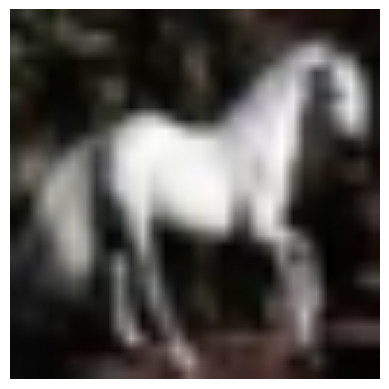

Label: horse


In [5]:
# Undo normalization for plotting
def imshow(img):
    
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Visual check
images, labels = next(iter(test_loader))

random_image = randint(0, len(images) - 1)
imshow(images[random_image])

print("Label:", test_dataset.classes[labels[[random_image]]])

In [7]:
# Load pre-trained ResNet-18
resnet101 = models.resnet101(pretrained=True)

# Remove final classification layer (fc)
# We’ll use everything up to the last FC layer
model = nn.Sequential(*list(resnet101.children())[:-1])  # Exclude the classifier

# Set to evaluation mode
model.eval()

# Send to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [8]:
print(model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [9]:
# Make sure model and dataloader are ready
model.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)

        # Pass through model to get features
        features = model(images)  # Output shape: [B, 512, 1, 1]
        features = features.squeeze()  # Remove [1,1] dimensions → [B, 512]

        if len(features.shape) == 1:
            features = features.unsqueeze(0)  # Handle batch size = 1

        all_embeddings.append(features.cpu())
        all_labels.append(labels)

# Stack into arrays
all_embeddings = torch.cat(all_embeddings, dim=0).numpy()  # Shape: [10000, 512]
all_labels = torch.cat(all_labels, dim=0).numpy()  # Shape: [10000]

100%|██████████| 157/157 [00:51<00:00,  3.07it/s]


In [ ]:
os.makedirs(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_Resnet101", exist_ok=True)
np.save(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_Resnet101\resnet101_cifar10_embeddings.npy", all_embeddings)
np.save(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_Resnet101\resnet101_cifar10_labels.npy", all_labels)

In [12]:
print(np.load("embeddings/resnet101_cifar10_embeddings.npy").shape)
print(np.load("embeddings/resnet101_cifar10_labels.npy").shape)

(10000, 2048)
(10000,)


In [4]:
embeddings = np.load(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_Resnet101\resnet101_cifar10_embeddings.npy")
labels = np.load(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_Resnet101\resnet101_cifar10_labels.npy")

In [5]:
unique_idxs = np.unique(labels)

print("Unique label indices and names:")
for idx in unique_idxs:
    print(f"{idx}: {test_dataset.classes[idx]}")

Unique label indices and names:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


In [6]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding_2d = reducer.fit_transform(embeddings)  # Shape: [10000, 2]

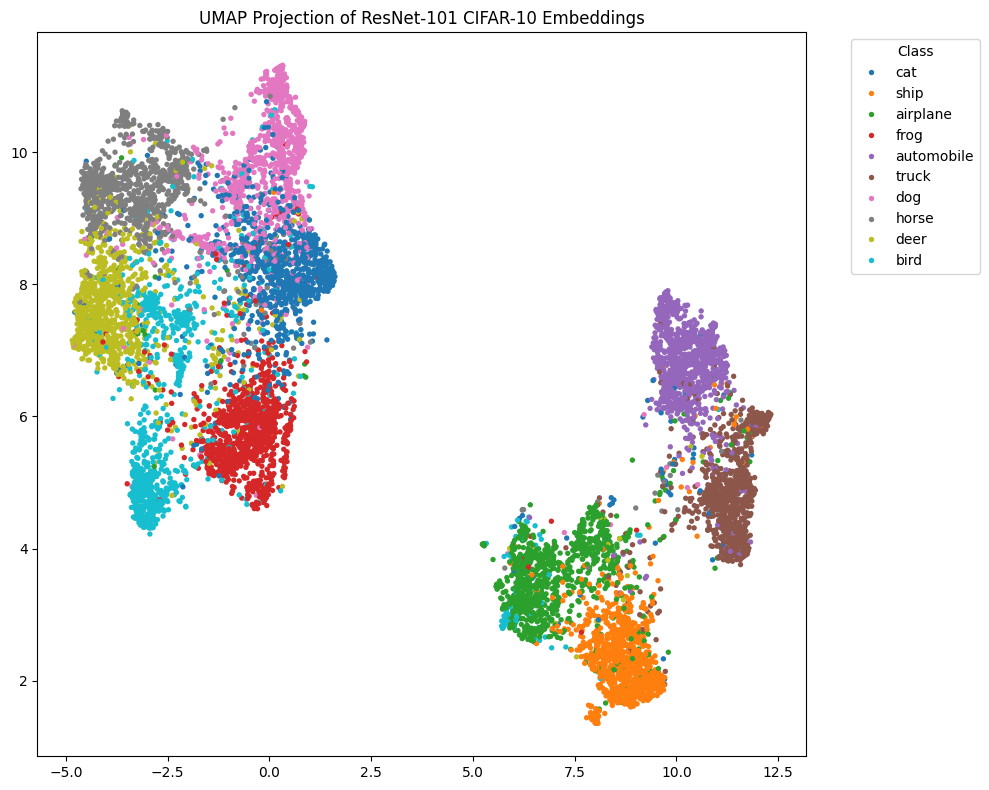

In [8]:
class_names = test_dataset.classes  # list of class names indexed by label id

# Convert numeric labels → class names
label_names = [class_names[i] for i in labels]


plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=embedding_2d[:, 0], 
    y=embedding_2d[:, 1], 
    hue=label_names, 
    palette='tab10', 
    s=15, 
    linewidth=0
)

plt.title("UMAP Projection of ResNet-101 CIFAR-10 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()

In [9]:
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', n_iter=1000)
tsne_2d = tsne.fit_transform(embeddings)

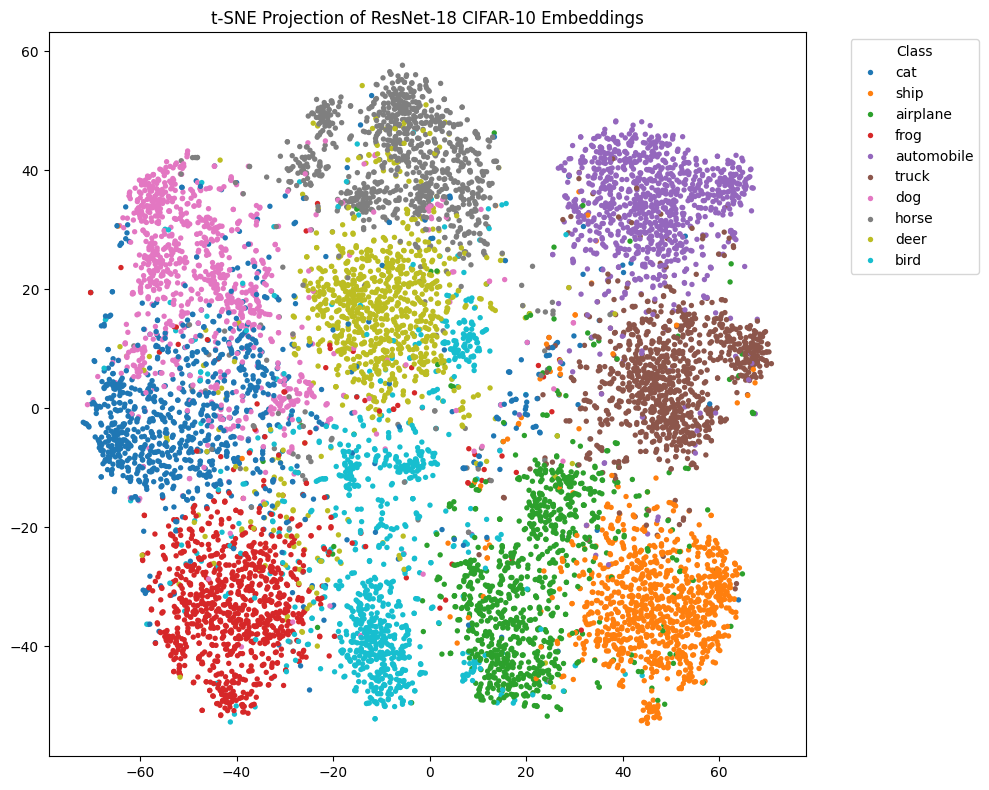

In [10]:
plt.figure(figsize=(10, 8))


sns.scatterplot(
    x=tsne_2d[:, 0], 
    y=tsne_2d[:, 1], 
    hue=label_names, 
    palette='tab10', 
    s=15, 
    linewidth=0
)

plt.title("t-SNE Projection of ResNet-18 CIFAR-10 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
# Map each class label to list of indices
label_to_indices = defaultdict(list)
for idx, label in enumerate(labels):
    label_to_indices[label].append(idx)

# Randomly pick one index per class (for top 10 classes)
class_to_idx = {}
top_k = 10
selected_labels = list(label_to_indices.keys())[:top_k]  # You can shuffle this if needed

for label in selected_labels:
    class_to_idx[label] = random.choice(label_to_indices[label])


top_k = 10
results = {}

for class_label, query_idx in class_to_idx.items():
    query_embedding = embeddings[query_idx].reshape(1, -1)

    # Compute cosine similarity to all embeddings
    similarities = cosine_similarity(query_embedding, embeddings)[0]  # shape: [10000]

    # Get top K most similar indices (excluding the query itself)
    similar_indices = similarities.argsort()[::-1][1:top_k+1]

    results[class_label] = {
        "query_idx": query_idx,
        "neighbors": similar_indices
    }
    
    
def unnormalize(img_tensor):
    """
    Undo normalization to convert image tensor to [0,1] range for imshow
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    return img_tensor


def show_neighbors(dataset, query_idx, neighbor_indices, class_name):
    plt.figure(figsize=(12, 2))

    # Query image
    plt.subplot(1, top_k + 1, 1)
    query_img = unnormalize(dataset[query_idx][0])
    plt.imshow(query_img.permute(1, 2, 0).numpy())
    plt.title(f"Query\nClass: {class_name}")
    plt.axis('off')

    # Neighbors
    for i, idx in enumerate(neighbor_indices):
        plt.subplot(1, top_k + 1, i + 2)
        nn_img = unnormalize(dataset[idx][0])
        plt.imshow(nn_img.permute(1, 2, 0).numpy())

        # Get the actual label name from dataset.labels or dataset.targets
        nn_label_idx = dataset[idx][1]  # This is the label index
        nn_label_name = dataset.classes[nn_label_idx]

        plt.title(f"NN {i+1}\n{nn_label_name}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

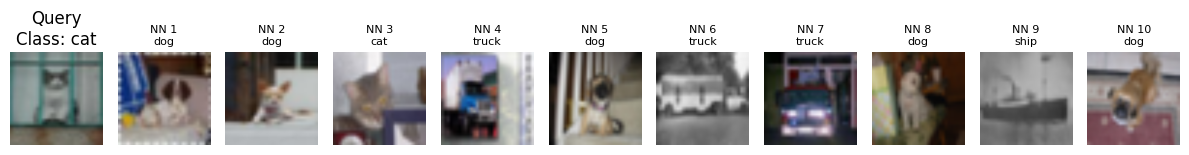

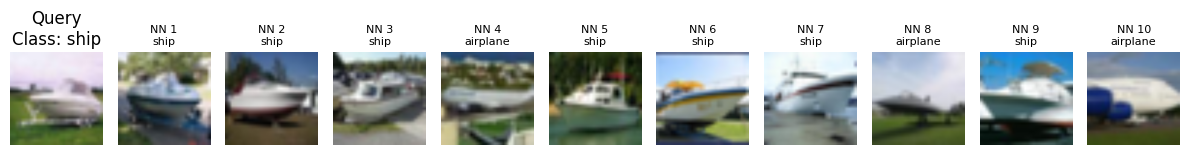

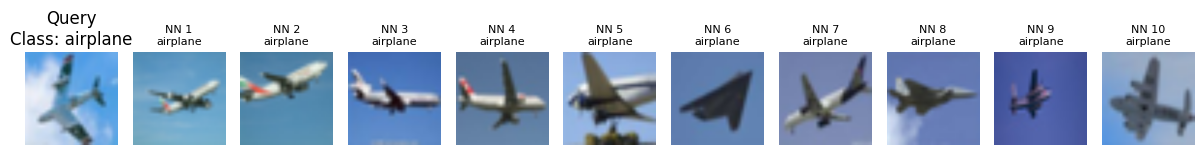

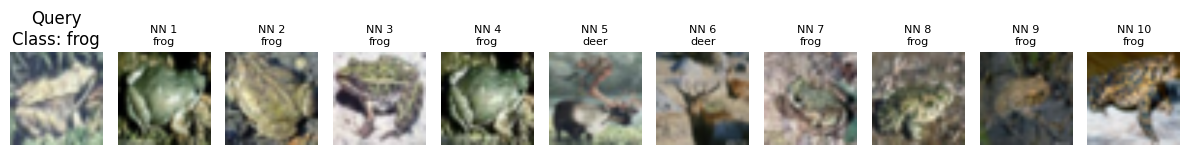

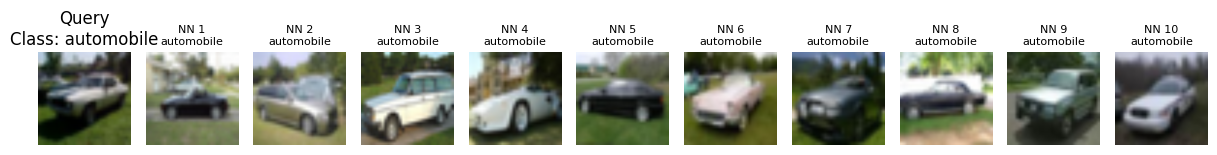

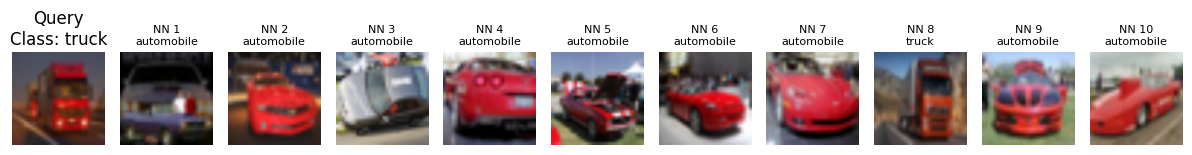

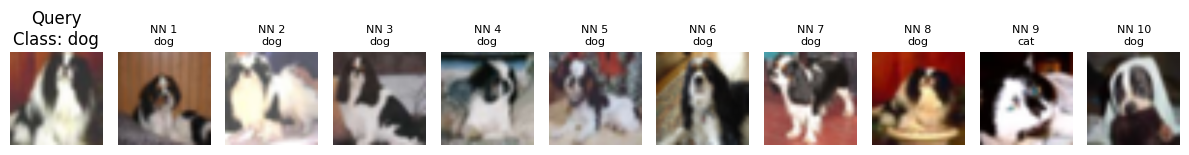

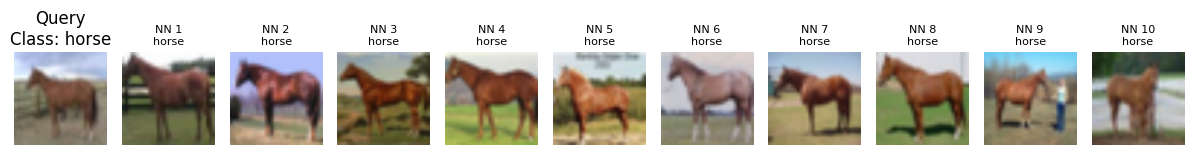

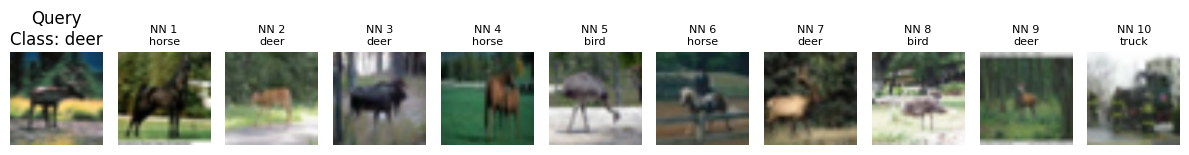

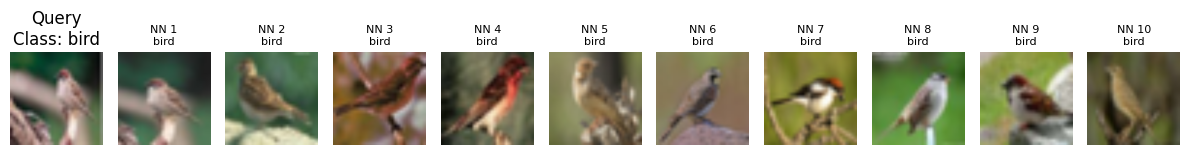

In [18]:
for class_label, data in results.items():
    show_neighbors(
        dataset=test_dataset,
        query_idx=data["query_idx"],
        neighbor_indices=data["neighbors"],
        class_name=test_dataset.classes[class_label]
    )

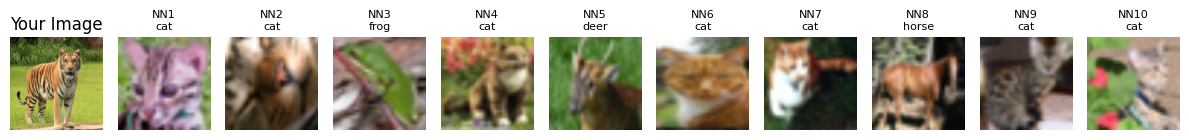

In [19]:
from PIL import Image

# Parameters
your_image_path = "tiger.jpg"  
top_k = 10

# 1. Load and preprocess your image
img = Image.open(your_image_path).convert("RGB")
img_t = transform(img).unsqueeze(0).to(device)  # reuse `transform` and `device` from above

# 2. Extract its embedding
model.eval()
with torch.no_grad():
    feat = model(img_t)         # [1, 512, 1, 1]
    feat = feat.squeeze().cpu().numpy().reshape(1, -1)

# 3. Compute cosine similarities to all saved embeddings
all_emb = embeddings          # loaded earlier: np.load("embeddings/...npy")
sims = cosine_similarity(feat, all_emb)[0]

# 4. Get top_k neighbor indices (skip the image itself if accidentally included)
neighbor_idxs = sims.argsort()[::-1][:top_k]

# 5. Display query + neighbors
plt.figure(figsize=(12, 2))

# Query
plt.subplot(1, top_k+1, 1)
plt.imshow(img.resize((224,224)))
plt.title("Your Image")
plt.axis("off")

# Neighbors
for i, idx in enumerate(neighbor_idxs):
    ds_img, ds_lbl = test_dataset[idx]
    nn_img = unnormalize(ds_img)  # reuse unnormalize function
    plt.subplot(1, top_k+1, i+2)
    plt.imshow(nn_img.permute(1,2,0).numpy())
    plt.title(f"NN{i+1}\n{test_dataset.classes[ds_lbl]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [2]:
# Prepare for transfer learning - freeze feature extractor and train only classifier
model = torchvision.models.resnet101(pretrained=True)

# Freeze all feature extractor layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer for CIFAR-10 (10 classes)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
# Define loss function and optimizer (only for classifier parameters)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Load CIFAR-10 training set for fine-tuning
train_dataset = torchvision.datasets.CIFAR10(
    root=r'C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Files already downloaded and verified


In [6]:
# Training loop
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

In [7]:
print("Training classifier head...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    scheduler.step()
    
    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_train_loss = running_loss / len(train_loader)
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc = 100. * correct / total
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

Training classifier head...


Epoch 1/10: 100%|██████████| 782/782 [04:08<00:00,  3.15it/s]


Epoch 1: Train Loss: 0.6680, Val Loss: 0.5145, Val Acc: 82.47%


Epoch 2/10: 100%|██████████| 782/782 [04:03<00:00,  3.21it/s]


Epoch 2: Train Loss: 0.5143, Val Loss: 0.4923, Val Acc: 83.23%


...

Epoch 8: Train Loss: 0.4220, Val Loss: 0.4386, Val Acc: 84.99%


Epoch 9/10: 100%|██████████| 782/782 [04:03<00:00,  3.21it/s]


Epoch 9: Train Loss: 0.4120, Val Loss: 0.4295, Val Acc: 85.61%


Epoch 10/10: 100%|██████████| 782/782 [04:04<00:00,  3.19it/s]


Epoch 10: Train Loss: 0.4123, Val Loss: 0.4329, Val Acc: 85.42%


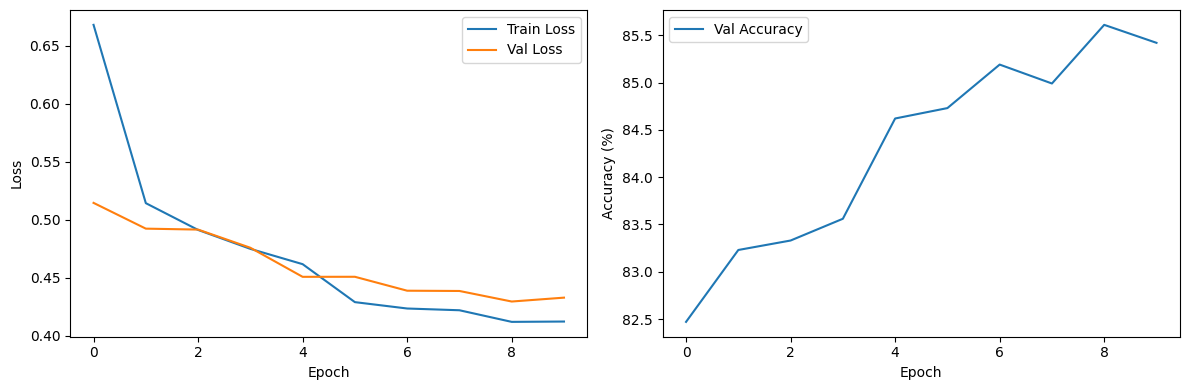

In [8]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Comprehensive evaluation on test set
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
accuracy = 100.0 * np.mean(all_preds == all_labels)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

print(f"\nFinal Test Accuracy: {accuracy:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Evaluating: 100%|██████████| 157/157 [00:46<00:00,  3.37it/s]


Final Test Accuracy: 85.42%
Weighted Precision: 0.8545
Weighted Recall: 0.8542
Weighted F1-Score: 0.8537

Classification Report:
              precision    recall  f1-score   support

    airplane       0.80      0.90      0.85      1000
  automobile       0.92      0.91      0.92      1000
        bird       0.83      0.79      0.81      1000
         cat       0.77      0.74      0.75      1000
        deer       0.85      0.79      0.82      1000
         dog       0.83      0.81      0.82      1000
        frog       0.90      0.91      0.91      1000
       horse       0.84      0.89      0.86      1000
        ship       0.89      0.92      0.90      1000
       truck       0.91      0.90      0.90      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



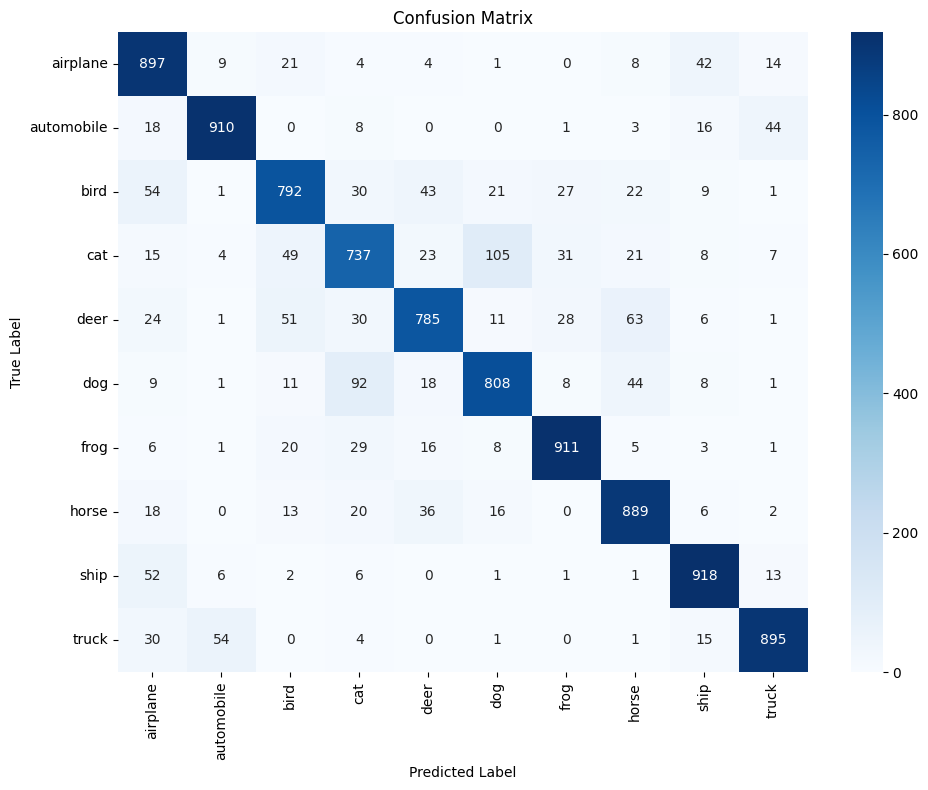

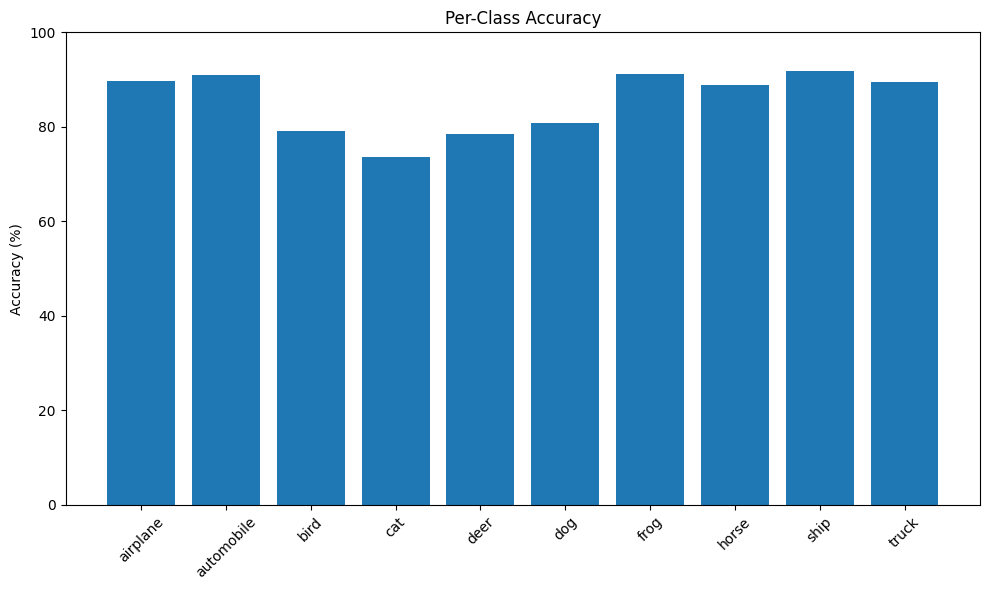

In [10]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_dataset.classes, 
            yticklabels=test_dataset.classes)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Per-class accuracy
class_correct = np.zeros(10)
class_total = np.zeros(10)
for i in range(10):
    idx = all_labels == i
    class_correct[i] = np.sum(all_preds[idx] == i)
    class_total[i] = np.sum(idx)

class_accuracies = 100 * class_correct / class_total

plt.figure(figsize=(10, 6))
plt.bar(range(10), class_accuracies)
plt.xticks(range(10), test_dataset.classes, rotation=45)
plt.title('Per-Class Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

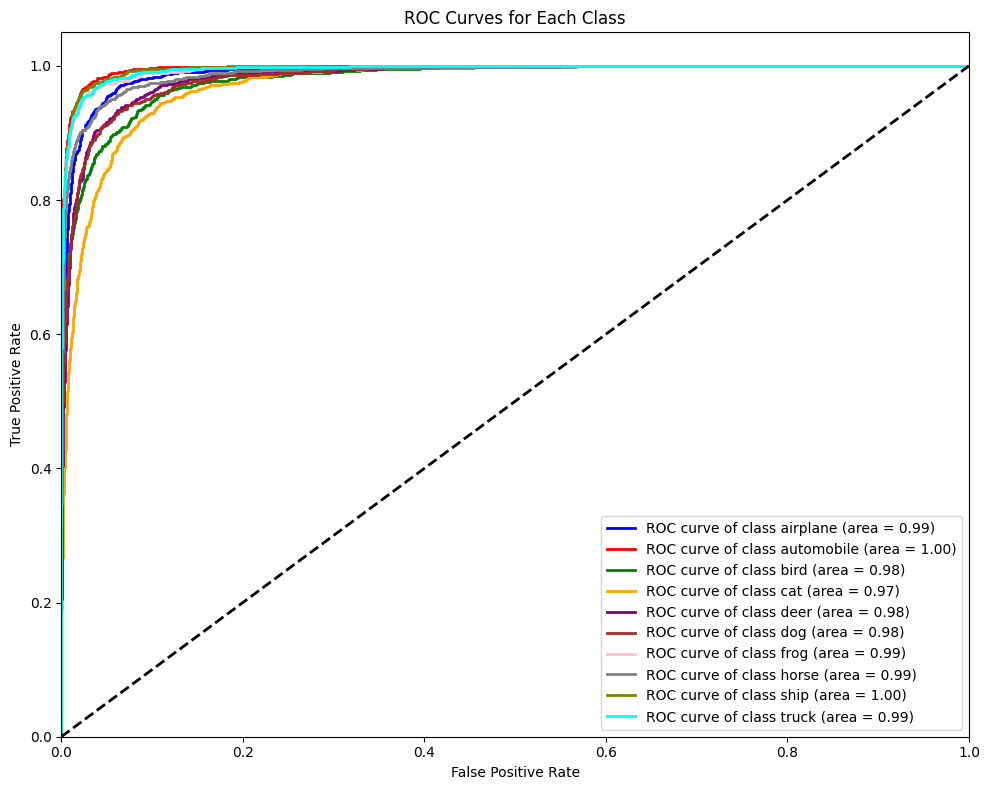


=== TRANSFER LEARNING EVALUATION SUMMARY ===
Test Accuracy: 85.42%
Weighted Precision: 0.8545
Weighted Recall: 0.8542
Weighted F1-Score: 0.8537
Mean ROC AUC: 0.9882


In [11]:
# ROC Curve (for binary classification we'd use this, for multi-class we need to adapt)
# For multi-class, we can show ROC for each class vs rest
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(all_labels, classes=range(10))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(test_dataset.classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Print final summary
print("\n=== TRANSFER LEARNING EVALUATION SUMMARY ===")
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")
print(f"Mean ROC AUC: {np.mean(list(roc_auc.values())):.4f}")